# Quad3D — CBF / Hand-CBF / R-CBF-QP / Duality CBF

Experiments with CBF safety filters on the 3D quadrotor (12-state).

**State**: `[px, py, pz, vx, vy, vz, φ, θ, ψ, p, q, r]`  
**Safety constraints**: altitude floor/ceiling, roll/pitch limits  
**Hand-designed CBF**: stopping-distance barrier for altitude (valid under max-thrust assumption)  

The notebook works without a trained checkpoint — cells that need one are clearly marked.  
Set `CKPT_PATH` below once training is complete.

In [14]:
import functools as ft
import sys
sys.path.insert(0, '../../src')

import flax.linen as nn
import jax
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt
import optax
import time

from mrncbf.dyn.quad3d import Quad3D
from mrncbf.utils.jax_utils import jax_default_x32, jax2np
from mrncbf.qp.min_norm_cbf import min_norm_cbf, gcbf_qp

jax_default_x32()

task = Quad3D()
print(f'nx={task.nx}  nu={task.nu}  nh={task.nh}  dt={task.dt}')
print('h_labels:', task.h_labels)

# ── QP / filter parameters ────────────────────────────────────────────────────
ALPHA_QP = 1.0     # hand-designed CBF is properly normalised — α=1 is fine
V_SHIFT  = 0.0

# ── Rollout parameters ────────────────────────────────────────────────────────
DT  = 0.001          # 100 Hz control (finer than task.dt=0.05)
T   = 1000           # steps  (DT*T = 10 s, same total time)
ts  = np.arange(T + 1) * DT

u_lb = jnp.array(task.u_min)   # [-1, -1, -1, -1]
u_ub = jnp.array(task.u_max)   # [ 1,  1,  1,  1]

# ── Measurement noise (small — used in altitude/attitude demo) ────────────────
STATE_EPS = jnp.array([
    0.05, 0.05, 0.05,   # position  (m)
    0.05, 0.05, 0.05,   # velocity  (m/s)
    0.02, 0.02, 0.02,   # angles    (rad)
    0.05, 0.05, 0.05,   # ang rates (rad/s)
])

BASE_KEY = jax.random.PRNGKey(0)

# ── Contour grid for phase portraits ─────────────────────────────────────────
bb_x0, bb_Xs, bb_Ys = task.get_contour_x0(setup=0, n_pts=50)   # pz-vz slice
print(f'Contour grid: {bb_Xs.shape}')


nx=12  nu=4  nh=6  dt=0.05
h_labels: ['floor', 'ceil', 'roll_lb', 'roll_ub', 'pitch_lb', 'pitch_ub']
Contour grid: (50, 50)


## Task verification

Sanity-check the dynamics: the hover equilibrium should be exactly fixed and the nominal PD policy should keep it there.

In [15]:
x_hover = jnp.array(task.eq_state())
f0  = task.f(x_hover)
G0  = task.G(x_hover)
u0  = task.nom_pol_hover(x_hover)
h0  = task.h_components(x_hover)
B0  = task.handcbf_B(x_hover)

print('f(x_hover)  :', np.array(f0).round(4))
print('u_nom(hover):', np.array(u0).round(4))
print('h(hover) max:', float(h0.max()), ' (should be < 0)')
print('B(hover) max:', float(B0.max()), ' (should be < 0)')

# Verify hover is truly an equilibrium: one-step Euler should not drift.
x1 = x_hover + DT * task.xdot(x_hover, u0)
print(f'After 1 step from hover — Δx max: {float(jnp.abs(x1 - x_hover).max()):.2e}  (should be ~0)')

f(x_hover)  : [ 0.  0.  0.  0.  0.  0.  0.  0.  0. -0.  0.  0.]
u_nom(hover): [-0.  0. -0. -0.]
h(hover) max: -0.9203628301620483  (should be < 0)
B(hover) max: -1.399999976158142  (should be < 0)
After 1 step from hover — Δx max: 0.00e+00  (should be ~0)


## Hand-designed CBF: stopping-distance barrier

Visualise the level sets of `B_floor` in the (pz, vz) plane.  
The `B=0` contour is the safe-set boundary: states above it are safe, below are flagged unsafe.

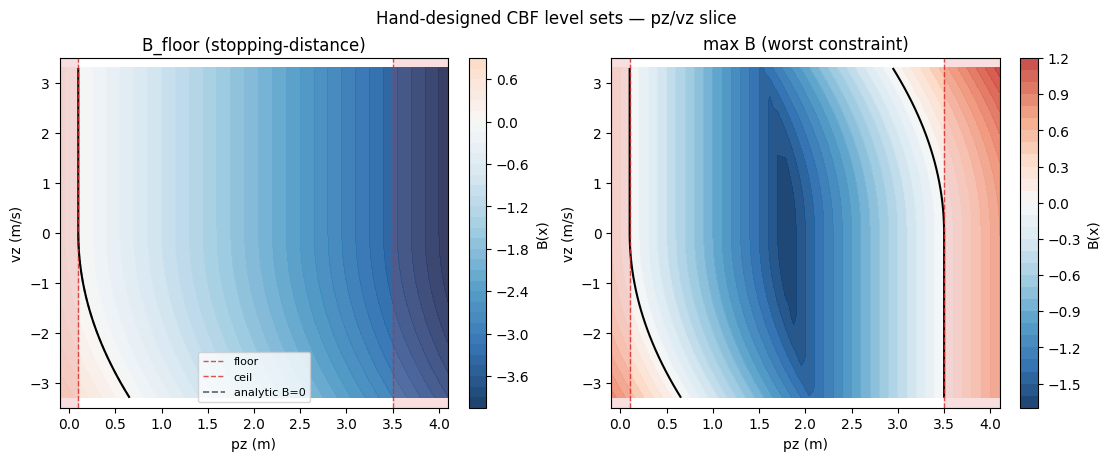

In [16]:
# Evaluate hand CBF over the pz-vz grid
bb_B = jax2np(jax.vmap(jax.vmap(task.handcbf_B))(bb_x0))   # (n, n, nh)
bb_B_max = bb_B.max(-1)                                       # (n, n)  worst constraint
bb_B_floor = bb_B[:, :, 0]                                    # floor constraint only

# Analytical stopping-distance boundary: pz - Z_MIN = vz_neg^2 / (2*g)
vz_line = np.linspace(-3.3, 0, 200)
pz_stop = task.Z_MIN + vz_line**2 / (2 * task.GRAV)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5), layout='constrained')

for ax, data, title in zip(axes,
                            [bb_B_floor, bb_B_max],
                            ['B_floor (stopping-distance)', 'max B (worst constraint)']):
    vmax = np.abs(data).max()
    cs = ax.contourf(bb_Xs, bb_Ys, data, levels=31,
                     cmap='RdBu_r', vmin=-vmax, vmax=vmax, alpha=0.9)
    ax.contour(bb_Xs, bb_Ys, data, levels=[0.0], colors=['k'], linewidths=1.5)
    fig.colorbar(cs, ax=ax, label='B(x)')
    task.plot_pz_vz(ax)
    ax.set_title(title)

# Overlay analytical stopping-distance line on left panel
axes[0].plot(pz_stop, vz_line, 'k--', lw=1.2, alpha=0.6, label='analytic B=0')
axes[0].legend(fontsize=8)

fig.suptitle('Hand-designed CBF level sets — pz/vz slice')
plt.show()

## Nominal policy rollouts from challenging initial conditions

Compiling rollouts...
Done.


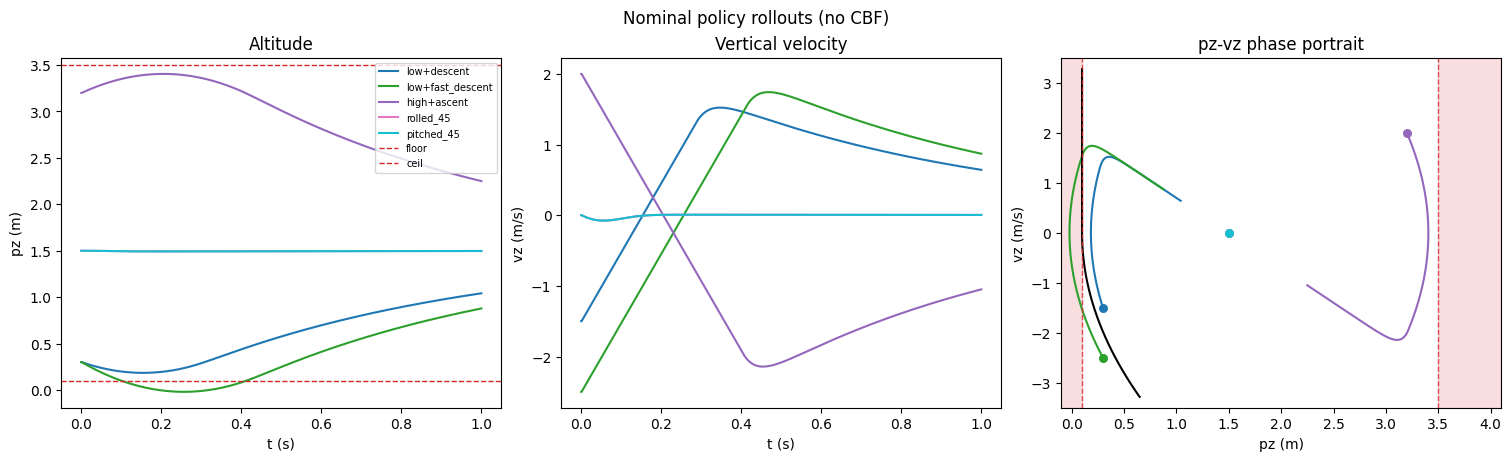

  low+descent             violated: 0  h_max: -0.085
  low+fast_descent        violated: 1  h_max: 0.120
  high+ascent             violated: 0  h_max: -0.095
  rolled_45               violated: 0  h_max: -0.261
  pitched_45              violated: 0  h_max: -0.261


In [17]:
# ── Rollout infrastructure ────────────────────────────────────────────────────
def _make_rollout(step_fn):
    """Build a jit-compiled lax.scan rollout; step returns (x_next, (x, xhat))."""
    @jax.jit
    def rollout(x0):
        _, (xs, xhats) = jax.lax.scan(step_fn, x0, jnp.arange(T))
        return jnp.concatenate([x0[None], xs], axis=0), xhats
    return rollout

def _perturb_state(x, key):
    delta = jax.random.uniform(key, x.shape, minval=-STATE_EPS, maxval=STATE_EPS)
    return x + 0.01*delta


# ── Nominal (no CBF, small obs noise) ────────────────────────────────────────
def _nom_step(x, step_idx):
    key  = jax.random.fold_in(BASE_KEY, step_idx)
    xhat = _perturb_state(x, key)
    u    = task.nom_pol_hover(xhat)
    return x + DT * task.xdot(x, u), (x, xhat)

# ── Hand-CBF ──────────────────────────────────────────────────────────────────
def _handcbf_step(x, step_idx):
    key   = jax.random.fold_in(BASE_KEY, step_idx)
    xhat  = _perturb_state(x, key)
    h_B   = task.handcbf_B(xhat) + V_SHIFT
    hx_Bx = jax.jacobian(task.handcbf_B)(xhat)
    u_nom = task.nom_pol_hover(xhat)
    u, _, _ = min_norm_cbf(ALPHA_QP, u_lb, u_ub, h_B, hx_Bx,
                            task.f(xhat), task.G(xhat), u_nom, relax_eps2=0.1)
    return x + DT * task.xdot(x, u), (x, xhat)

rollout_nom     = _make_rollout(_nom_step)
rollout_handcbf = _make_rollout(_handcbf_step)

print("Compiling rollouts...")
rollout_nom(x_hover)
rollout_handcbf(x_hover)
print("Done.")

# ── Initial conditions ────────────────────────────────────────────────────────
x0s = [
    x_hover.at[task.PZ].set(0.3).at[task.VZ].set(-1.5),    # low, descending
    x_hover.at[task.PZ].set(0.3).at[task.VZ].set(-2.5),    # low, fast descent
    x_hover.at[task.PZ].set(3.2).at[task.VZ].set( 2.0),    # high, ascending
    x_hover.at[task.PZ].set(1.5).at[task.PHI].set(np.pi/4),   # rolled 45°
    x_hover.at[task.PZ].set(1.5).at[task.THETA].set(np.pi/4), # pitched 45°
]
labels = ["low+descent", "low+fast_descent", "high+ascent", "rolled_45", "pitched_45"]

# ── Nominal rollout plot ───────────────────────────────────────────────────────
trajs_nom = []
for x0_i in x0s:
    xs, _ = jax2np(rollout_nom(x0_i))
    trajs_nom.append(xs)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), layout="constrained")
colors = plt.cm.tab10(np.linspace(0, 0.9, len(x0s)))

for T_x, lbl, c in zip(trajs_nom, labels, colors):
    axes[0].plot(ts, T_x[:, task.PZ],  color=c, lw=1.5, label=lbl)
    axes[1].plot(ts, T_x[:, task.VZ],  color=c, lw=1.5)
    axes[2].plot(T_x[:, task.PZ], T_x[:, task.VZ], color=c, lw=1.5)
    axes[2].scatter(T_x[0, task.PZ], T_x[0, task.VZ], s=30, color=c, zorder=5)

axes[0].axhline(task.Z_MIN, color="C3", ls="--", lw=1.0, label="floor")
axes[0].axhline(task.Z_MAX, color="C3", ls="--", lw=1.0, label="ceil")
axes[0].set(xlabel="t (s)", ylabel="pz (m)", title="Altitude"); axes[0].legend(fontsize=7)
axes[1].set(xlabel="t (s)", ylabel="vz (m/s)", title="Vertical velocity")
axes[2].contour(bb_Xs, bb_Ys, bb_B_floor, levels=[0.0], colors=["k"], linewidths=1.5)
task.plot_pz_vz(axes[2]); axes[2].set_title("pz-vz phase portrait")
fig.suptitle("Nominal policy rollouts (no CBF)"); plt.show()

for T_x, lbl in zip(trajs_nom, labels):
    h_traj = jax2np(jax.vmap(task.h_components)(jnp.array(T_x)))
    print(f"  {lbl:<22}  violated: {h_traj.max(-1).max() > 0:.0f}  "
          f"h_max: {h_traj.max():.3f}")

## Hand-CBF safety filter

Apply the stopping-distance CBF via a min-norm QP on top of the nominal policy.

  Nominal       safe: 4/5
  Hand-CBF      safe: 4/5


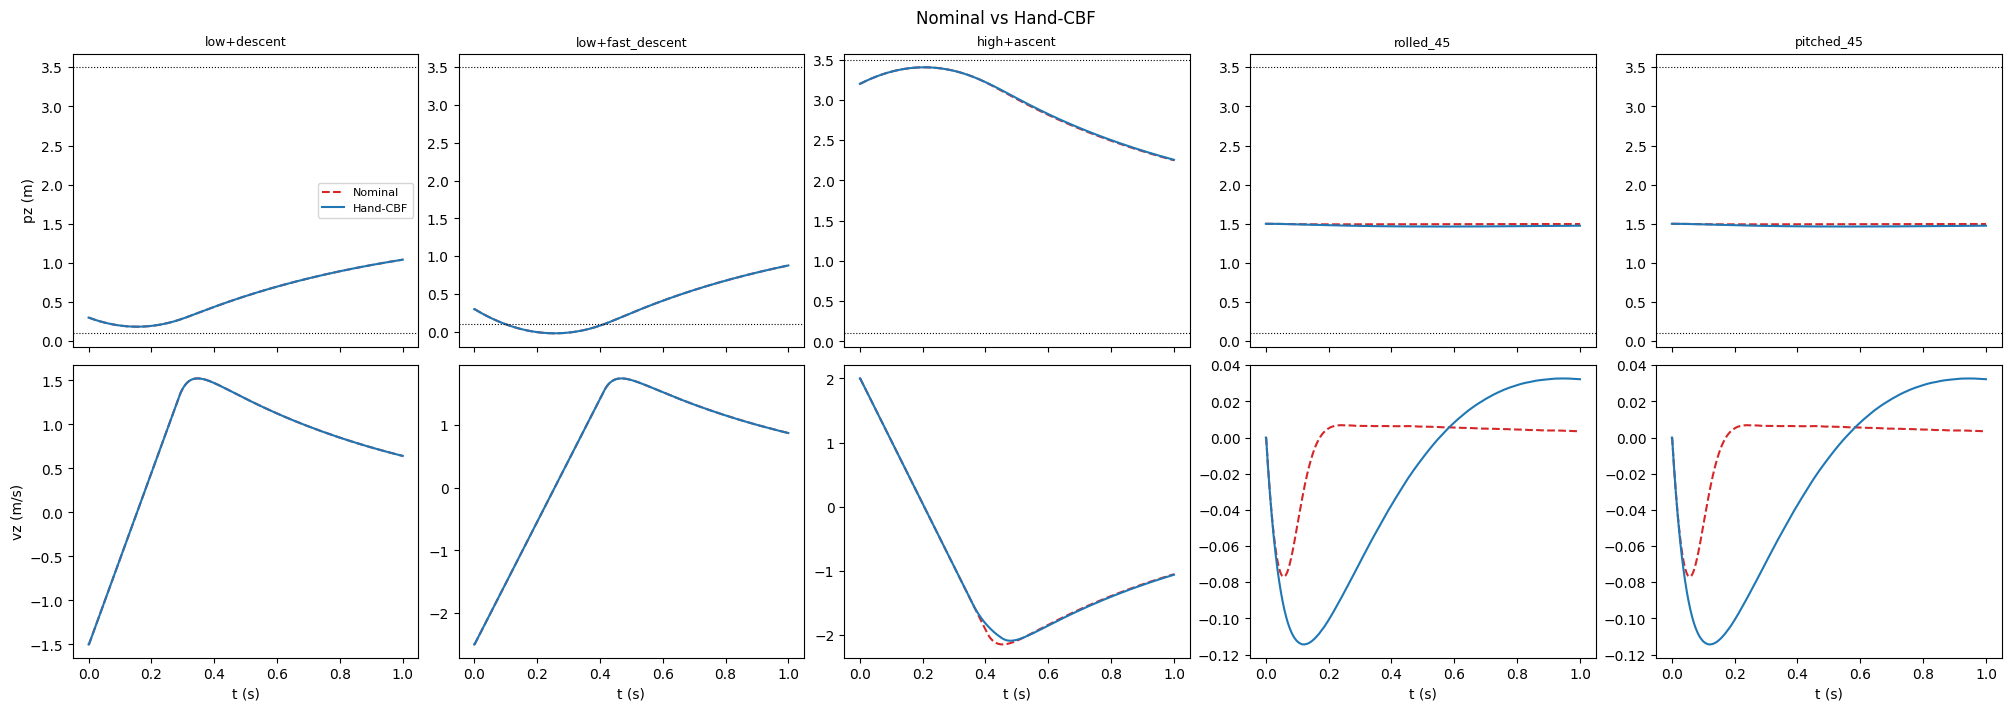

In [18]:
# ── Nominal vs Hand-CBF comparison ───────────────────────────────────────────
results_hand = {}
for name, fn in [("Nominal", rollout_nom), ("Hand-CBF", rollout_handcbf)]:
    trajs = []
    for x0_i in x0s:
        xs, _ = jax2np(fn(x0_i))
        h_traj = jax2np(jax.vmap(task.h_components)(jnp.array(xs)))
        violated = bool(np.any(h_traj.max(-1) > 0))
        trajs.append((xs, violated))
    results_hand[name] = trajs
    n_safe = sum(1 for _, v in trajs if not v)
    print(f"  {name:<12}  safe: {n_safe}/{len(x0s)}")

fig, axes = plt.subplots(2, len(x0s), figsize=(4*len(x0s), 7), layout="constrained",
                         sharex=True)
_ls = {"Nominal": ("C3", "--"), "Hand-CBF": ("C0", "-")}
for col, (x0_i, lbl) in enumerate(zip(x0s, labels)):
    for name, trajs in results_hand.items():
        xs = trajs[col][0]
        color, ls = _ls[name]
        axes[0, col].plot(ts, xs[:, task.PZ], color=color, ls=ls, lw=1.5, label=name)
        axes[1, col].plot(ts, xs[:, task.VZ], color=color, ls=ls, lw=1.5)
    axes[0, col].axhline(task.Z_MIN, color="k", ls=":", lw=0.8)
    axes[0, col].axhline(task.Z_MAX, color="k", ls=":", lw=0.8)
    axes[0, col].set_title(lbl, fontsize=9)
    axes[1, col].set_xlabel("t (s)")
axes[0, 0].set_ylabel("pz (m)"); axes[1, 0].set_ylabel("vz (m/s)")
axes[0, 0].legend(fontsize=8)
fig.suptitle("Nominal vs Hand-CBF"); plt.show()

## Obstacle avoidance (hand-CBF)

A sphere obstacle at (1 m, 0, 1.4 m) with radius 0.4 m intersects the quad's nominal
flight path (hover return from high vx).  The hand-designed HOCBF prevents the collision.

The obstacle is placed slightly *below* hover height (cz = 1.4 < Z\_HOVER = 1.5) so the
approach direction has a vertical component — this gives the upward thrust a lever arm to
steer the quad away from the obstacle.

nh=7  labels=['floor', 'ceil', 'roll_lb', 'roll_ub', 'pitch_lb', 'pitch_ub', 'obs_0']
Compiling obstacle rollouts...
Done.
  Nominal       safe: 0/3
  Hand-CBF      safe: 3/3


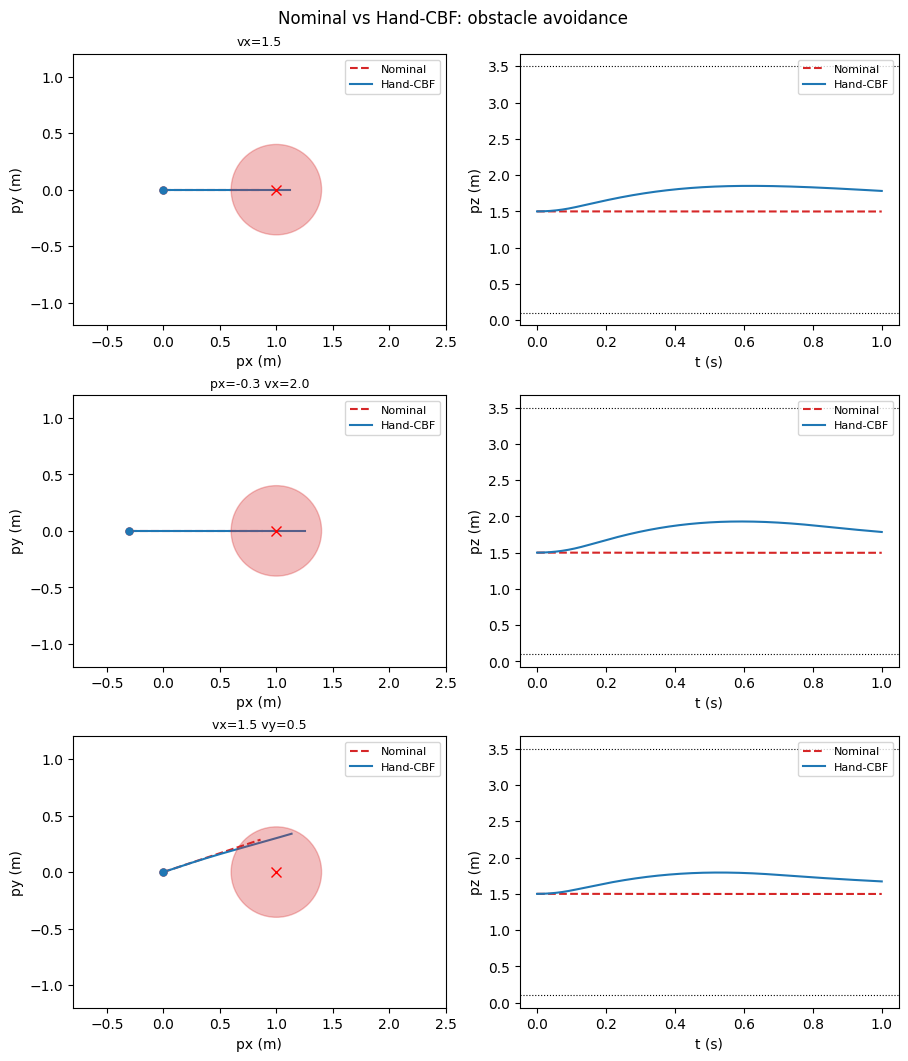

In [19]:
# Obstacle slightly below hover height so thrust has avoidance authority
task_obs = Quad3D(obstacles=[(1.0, 0.0, 1.4, 0.4)])
print(f'nh={task_obs.nh}  labels={task_obs.h_labels}')

def _nom_obs_step(x, step_idx):
    key  = jax.random.fold_in(BASE_KEY, step_idx)
    xhat = _perturb_state(x, key)
    u    = task_obs.nom_pol_hover(xhat)
    return x + DT * task_obs.xdot(x, u), (x, xhat)

def _handcbf_obs_step(x, step_idx):
    key   = jax.random.fold_in(BASE_KEY, step_idx)
    xhat  = _perturb_state(x, key)
    h_B   = task_obs.handcbf_B(xhat) + V_SHIFT
    hx_Bx = jax.jacobian(task_obs.handcbf_B)(xhat)
    u_nom = task_obs.nom_pol_hover(xhat)
    u, _, _ = min_norm_cbf(ALPHA_QP, u_lb, u_ub, h_B, hx_Bx,
                            task_obs.f(xhat), task_obs.G(xhat), u_nom, relax_eps2=0.1)
    return x + DT * task_obs.xdot(x, u), (x, xhat)

rollout_nom_obs     = _make_rollout(_nom_obs_step)
rollout_handcbf_obs = _make_rollout(_handcbf_obs_step)

x_obs_base = jnp.array(task_obs.eq_state())
x0s_obs = [
    x_obs_base.at[task.VX].set(1.5),
    x_obs_base.at[task.VX].set(2.0).at[task.PX].set(-0.3),
    x_obs_base.at[task.VX].set(1.5).at[task.VY].set(0.5),
]
labels_obs = ['vx=1.5', 'px=-0.3 vx=2.0', 'vx=1.5 vy=0.5']

print('Compiling obstacle rollouts...')
rollout_nom_obs(x_obs_base)
rollout_handcbf_obs(x_obs_base)
print('Done.')

# ── Run and plot ──────────────────────────────────────────────────────────────
results_obs = {}
for name, fn in [('Nominal', rollout_nom_obs), ('Hand-CBF', rollout_handcbf_obs)]:
    trajs = []
    for x0_i in x0s_obs:
        xs, _ = jax2np(fn(x0_i))
        h_traj = jax2np(jax.vmap(task_obs.h_components)(jnp.array(xs)))
        violated = bool(np.any(h_traj.max(-1) > 0))
        trajs.append((xs, violated))
    results_obs[name] = trajs
    n_safe = sum(1 for _, v in trajs if not v)
    print(f'  {name:<12}  safe: {n_safe}/{len(x0s_obs)}')

cx, cy, cz, r_obs = task_obs.obstacles[0]
_ls = {'Nominal': ('C3', '--'), 'Hand-CBF': ('C0', '-')}

fig, axes = plt.subplots(len(x0s_obs), 2, figsize=(9, 3.5*len(x0s_obs)), layout='constrained')
for row, (x0_i, lbl) in enumerate(zip(x0s_obs, labels_obs)):
    ax_xy = axes[row, 0];  ax_pz = axes[row, 1]
    for name, trajs in results_obs.items():
        xs, viol = trajs[row]
        col, ls = _ls[name]
        ax_xy.plot(xs[:, task_obs.PX], xs[:, task_obs.PY], color=col, ls=ls, lw=1.5, label=name)
        ax_xy.scatter(xs[0, task_obs.PX], xs[0, task_obs.PY], s=25, color=col, zorder=5)
        ax_pz.plot(ts, xs[:, task_obs.PZ], color=col, ls=ls, lw=1.5, label=name)
    circle = plt.Circle((cx, cy), r_obs, color='C3', alpha=0.3, zorder=3)
    ax_xy.add_patch(circle);  ax_xy.plot(cx, cy, 'rx', ms=7, zorder=4)
    ax_xy.set(xlim=(-0.8, 2.5), ylim=(-1.2, 1.2), xlabel='px (m)', ylabel='py (m)', aspect='equal')
    ax_xy.set_title(lbl, fontsize=9);  ax_xy.legend(fontsize=8)
    ax_pz.axhline(task_obs.Z_MIN, color='k', ls=':', lw=0.8)
    ax_pz.axhline(task_obs.Z_MAX, color='k', ls=':', lw=0.8)
    ax_pz.set(xlabel='t (s)', ylabel='pz (m)');  ax_pz.legend(fontsize=8)
fig.suptitle('Nominal vs Hand-CBF: obstacle avoidance')
plt.show()

## Duality CBF — robust to measurement noise

With noisy state estimates the naive CBF (applied at point estimate $\hat{x}$) may violate
safety: the true state can be in a dangerous region while $\hat{x}$ appears safe.

The **Duality CBF** finds the worst-case true state inside the uncertainty box
$\hat{x} \pm \varepsilon$ for each CBF constraint $i$ and dual direction
$d \in S^{n_u}$ (unit vectors in $\mathbb{R}^{n_u+1}$):

$$x^* = \operatorname*{argmax}_{x \in [\hat{x}-\varepsilon,\,\hat{x}+\varepsilon]}
\; d_{1:n_u} \cdot L_G h_i(x) \;+\; d_{n_u+1}\,\bigl(L_f h_i(x) + \alpha\, h_i(x)\bigr)$$

The CBF-QP is then built from the ingredients $(h_i, L_f h_i, L_G h_i)$ evaluated at every
worst-case $x^*$, covering all $N_h \times N_d$ constraint–direction pairs via `jax.vmap`.

In [31]:
# ── HOCBF alpha — shared by rollouts and the MC filter cell ─────────────────
hocbf_alpha = 2.0  # change here; re-run this cell + MC cell to take effect

# ── Larger noise for a convincing robustness demo ────────────────────────────
STATE_EPS_DUAL = jnp.array([
    0.15, 0.15, 0.15,   # position  (m)   — 37% of obstacle radius
    0.15, 0.15, 0.15,   # velocity  (m/s)
    0.04, 0.04, 0.04,   # angles    (rad)
    0.04, 0.04, 0.04,   # ang rates (rad/s)
])

def _perturb_dual(x, key):
    return x + jax.random.uniform(key, x.shape, minval=-STATE_EPS_DUAL, maxval=STATE_EPS_DUAL)

# ── Projected gradient ascent over a box ─────────────────────────────────────
def proj_grad_max_box(scalar_fn, lo, hi, n_restarts, n_steps, lr, key):
    """Maximise scalar_fn over box [lo, hi] via projected gradient ascent."""
    x0s = lo[None] + jax.random.uniform(key, (n_restarts, lo.shape[0])) * (hi - lo)
    def run_one(x0):
        def step(x, _):
            g = jax.grad(scalar_fn)(x)
            return jnp.clip(x + lr * g, lo, hi), None
        x_star, _ = jax.lax.scan(step, x0, None, length=n_steps)
        return scalar_fn(x_star), x_star
    vals, xs = jax.vmap(run_one)(x0s)
    best = jnp.argmax(vals)
    return vals[best], xs[best]

# ── CBF ingredients for the obstacle task ────────────────────────────────────
def _gcbf_obs_ingredients(x):
    h   = task_obs.handcbf_B(x, hocbf_alpha)
    hx  = jax.jacobian(lambda xi: task_obs.handcbf_B(xi, hocbf_alpha))(x)
    return h, hx @ task_obs.f(x), hx @ task_obs.G(x)

# ── Dual directions on S^4 (nu+1 = 5 for quad) ───────────────────────────────
N_PLANES_DUAL = 8
_rng_dirs     = np.random.default_rng(0)
_raw          = _rng_dirs.standard_normal((N_PLANES_DUAL, task_obs.nu + 1))
_DUAL_DIRS    = (_raw / np.linalg.norm(_raw, axis=1, keepdims=True)).astype(np.float32)

_NH_OBS = task_obs.nh   # 7
_nu_obs = task_obs.nu   # 4

# Repeat indices so vmap runs over all (constraint, direction) pairs at once
_IJ_CI   = jnp.repeat(jnp.arange(_NH_OBS), N_PLANES_DUAL)                         # (56,)
_IJ_DIRS = jnp.tile(jnp.array(_DUAL_DIRS, dtype=jnp.float32), (_NH_OBS, 1))       # (56, 5)

# ── Step functions ────────────────────────────────────────────────────────────
def _nom_dual_step(x, step_idx):
    key  = jax.random.fold_in(BASE_KEY, step_idx)
    xhat = _perturb_dual(x, key)
    u    = task_obs.nom_pol_hover(xhat)
    return x + DT * task_obs.xdot(x, u), (x, xhat)

def _cbf_noisy_step(x, step_idx):
    """Naive hand-CBF applied at noisy estimate — no noise awareness."""
    key   = jax.random.fold_in(BASE_KEY, step_idx)
    xhat  = _perturb_dual(x, key)
    h_B   = task_obs.handcbf_B(xhat, hocbf_alpha) + V_SHIFT
    hx_Bx = jax.jacobian(lambda xi: task_obs.handcbf_B(xi, hocbf_alpha))(xhat)
    u_nom = task_obs.nom_pol_hover(xhat)
    u, _, _ = min_norm_cbf(ALPHA_QP, u_lb, u_ub, h_B, hx_Bx,
                            task_obs.f(xhat), task_obs.G(xhat), u_nom, relax_eps2=0.1)
    return x + DT * task_obs.xdot(x, u), (x, xhat)

def _duality_step(x, step_idx):
    """Duality CBF: worst-case over uncertainty box for each (constraint, direction) pair."""
    key = jax.random.fold_in(BASE_KEY, step_idx)
    noise_key, opt_key = jax.random.split(key)
    xhat = _perturb_dual(x, noise_key)
    lo   = jnp.clip(xhat - STATE_EPS_DUAL, task_obs.train_bounds()[0], task_obs.train_bounds()[1])
    hi   = jnp.clip(xhat + STATE_EPS_DUAL, task_obs.train_bounds()[0], task_obs.train_bounds()[1])
    u_nom = task_obs.nom_pol_hover(xhat)

    all_keys = jax.random.split(opt_key, _NH_OBS * N_PLANES_DUAL)

    def _worst_one(ci, d_vec, k_j):
        """Find x* maximising the dual objective for constraint ci, direction d_vec."""
        def _obj(xi):
            h, Lf_h, LG_h = _gcbf_obs_ingredients(xi)
            return jnp.dot(d_vec[:_nu_obs], LG_h[ci]) + d_vec[_nu_obs] * (Lf_h[ci] + ALPHA_QP * h[ci])
        _, x_star = proj_grad_max_box(_obj, lo, hi, n_restarts=4, n_steps=25, lr=0.03, key=k_j)
        h_s, Lf_s, LG_s = _gcbf_obs_ingredients(x_star)
        return h_s[ci], Lf_s[ci], LG_s[ci]

    h_all, Lf_all, LG_all = jax.vmap(_worst_one)(_IJ_CI, _IJ_DIRS, all_keys)
    u, _, _ = gcbf_qp(ALPHA_QP, u_lb, u_ub, h_all, Lf_all, LG_all, u_nom, relax_eps2=0.1)
    return x + DT * task_obs.xdot(x, u), (x, xhat)

rollout_nom_dual  = _make_rollout(_nom_dual_step)
rollout_cbf_noisy = _make_rollout(_cbf_noisy_step)
rollout_duality   = _make_rollout(_duality_step)

print(f'Compiling duality CBF ({_NH_OBS}×{N_PLANES_DUAL}={_NH_OBS*N_PLANES_DUAL} pairs)...')
rollout_nom_dual(x_obs_base)
print('  nom done')
rollout_cbf_noisy(x_obs_base)
print('  hand-CBF (noisy) done')
rollout_duality(x_obs_base)
print('  duality done')

Compiling duality CBF (7×8=56 pairs)...
  nom done
  hand-CBF (noisy) done
  duality done


## Monte Carlo safety evaluation

Run each policy from N=1000 randomly sampled initial conditions and check **true safety** (`h_components > 0` = physical constraint violated — inside obstacle, outside altitude band, or past attitude limits). This is the loose criterion, not the HOCBF tightness check.

Candidates: 20000  |  inside CBF safe set: 9026  (45.1%)
Using 1000 ICs, all with handcbf_B(x0).max() < 0.
Compiling + running Monte Carlo rollouts...
  Nom+noise done.
  CBF+noise done.
  Duality CBF done.
Evaluating safety...
  Nom+noise       violations:  145/1000  
               rate:  14.5%  95% CI: [12.5%, 16.8%]
  CBF+noise       violations:    6/1000  
               rate:   0.6%  95% CI: [0.3%, 1.3%]
  Duality CBF     violations:    2/1000  
               rate:   0.2%  95% CI: [0.1%, 0.7%]


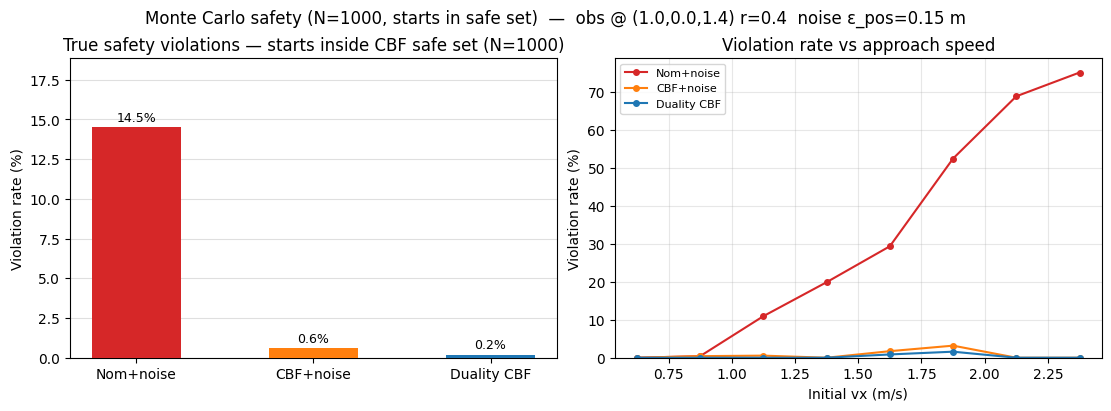

In [32]:
# ── Sample initial conditions that lie inside the CBF safe set ────────────────
# Only accept x0 with handcbf_B(x0).max() < 0 (inside CBF-invariant set).
# This filters out ICs that are already unsafe or approaching too fast —
# those are "doomed to fail" regardless of policy, so they don't test noise
# robustness.  The true-safety check (h_components) is then meaningful.

N_MC      = 1000
N_CAND    = 20_000      # oversample — many candidates won't pass the filter
# hocbf_alpha is defined in the duality cell above — change it there
rng_mc    = np.random.default_rng(42)
x_base    = jnp.array(task_obs.eq_state())

# Sample candidate ICs: vary approach direction, speed, altitude, lateral vel.
vx_cand = rng_mc.uniform(0.5,  3.0,  N_CAND)
px_cand = rng_mc.uniform(-0.5, 0.2,  N_CAND)
vy_cand = rng_mc.uniform(-0.8, 0.8,  N_CAND)
pz_cand = rng_mc.uniform(1.1,  2.0,  N_CAND)
vz_cand = rng_mc.uniform(-0.5, 0.5,  N_CAND)

x0s_cand = jnp.array([
    x_base.at[task_obs.VX].set(vx).at[task_obs.PX].set(px)
           .at[task_obs.VY].set(vy).at[task_obs.PZ].set(pz)
           .at[task_obs.VZ].set(vz)
    for vx, px, vy, pz, vz in zip(vx_cand, px_cand, vy_cand, pz_cand, vz_cand)
])

# Filter: keep only ICs inside the CBF invariant set (handcbf_B.max() < 0)
B0 = jax2np(jax.vmap(task_obs.handcbf_B, in_axes=(0, None))(x0s_cand, hocbf_alpha))  # (N_CAND, nh)
safe_mask = B0.max(axis=1) < 0
n_safe = safe_mask.sum()
print(f'Candidates: {N_CAND}  |  inside CBF safe set: {n_safe}  ({100*n_safe/N_CAND:.1f}%)')

assert n_safe >= N_MC, (
    f'Only {n_safe} safe ICs found — increase N_CAND or widen the sample region.')

safe_idx  = np.where(safe_mask)[0][:N_MC]
x0s_mc    = x0s_cand[safe_idx]
vx_mc     = vx_cand[safe_idx]      # keep for the vx-binned plot below
print(f'Using {N_MC} ICs, all with handcbf_B(x0).max() < 0.')

# ── Run rollouts with vmap ─────────────────────────────────────────────────────
mc_rollout_nom     = jax.jit(jax.vmap(rollout_nom_dual))
mc_rollout_cbf     = jax.jit(jax.vmap(rollout_cbf_noisy))
mc_rollout_duality = jax.jit(jax.vmap(rollout_duality))

print('Compiling + running Monte Carlo rollouts...')
mc_trajs = {}
for name, fn in [('Nom+noise',   mc_rollout_nom),
                 ('CBF+noise',   mc_rollout_cbf),
                 ('Duality CBF', mc_rollout_duality)]:
    xs_all, _ = jax2np(fn(x0s_mc))   # (N_MC, T+1, nx)
    mc_trajs[name] = xs_all
    print(f'  {name} done.')

# ── Evaluate true safety: h_components > 0 at any timestep ───────────────────
print('Evaluating safety...')
h_vmap = jax.jit(jax.vmap(jax.vmap(task_obs.h_components)))  # (N, T+1, nh)

mc_results = {}
for name, xs_all in mc_trajs.items():
    h_all   = jax2np(h_vmap(jnp.array(xs_all)))     # (N_MC, T+1, nh)
    violated = h_all.max(axis=(1, 2)) > 0            # (N_MC,) bool
    mc_results[name] = violated
    n_viol = violated.sum()
    rate   = n_viol / N_MC
    z = 1.96
    lo = (rate + z**2/(2*N_MC) - z*np.sqrt(rate*(1-rate)/N_MC + z**2/(4*N_MC**2))) / (1 + z**2/N_MC)
    hi = (rate + z**2/(2*N_MC) + z*np.sqrt(rate*(1-rate)/N_MC + z**2/(4*N_MC**2))) / (1 + z**2/N_MC)
    print(f'  {name:<14}  violations: {n_viol:4}/{N_MC}  ')
    print(f'               rate: {100*rate:5.1f}%  95% CI: [{100*lo:.1f}%, {100*hi:.1f}%]')

# ── Bar chart + violation vs approach speed ───────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(11, 4), layout='constrained')
names  = list(mc_results.keys())
colors = ['C3', 'C1', 'C0']
rates  = [mc_results[n].mean() for n in names]

axes[0].bar(names, [100*r for r in rates], color=colors, width=0.5, zorder=3)
axes[0].set(ylabel='Violation rate (%)',
            title=f'True safety violations — starts inside CBF safe set (N={N_MC})')
axes[0].set_ylim(0, max(100*max(rates)*1.3, 3))
axes[0].grid(axis='y', alpha=0.4, zorder=0)
for i, r in enumerate(rates):
    axes[0].text(i, 100*r + 0.2, f'{100*r:.1f}%', ha='center', va='bottom', fontsize=9)

bins = np.linspace(0.5, 3.0, 11)
bin_centers = 0.5*(bins[:-1] + bins[1:])
bin_idx_arr = np.digitize(vx_mc, bins) - 1
for name, color in zip(names, colors):
    viol = mc_results[name].astype(float)
    bin_rate = [viol[bin_idx_arr == b].mean() if (bin_idx_arr == b).any() else np.nan
                for b in range(len(bins)-1)]
    axes[1].plot(bin_centers, [100*r for r in bin_rate],
                 color=color, marker='o', ms=4, lw=1.5, label=name)

axes[1].set(xlabel='Initial vx (m/s)', ylabel='Violation rate (%)',
            title='Violation rate vs approach speed')
axes[1].legend(fontsize=8)
axes[1].grid(alpha=0.3)
axes[1].set_ylim(bottom=0)
fig.suptitle(
    f'Monte Carlo safety (N={N_MC}, starts in safe set)  —  ' +
    f'obs @ ({cx},{cy},{cz}) r={r_obs}  noise ε_pos={float(STATE_EPS_DUAL[0]):.2f} m')
plt.show()

## φ learning: amortising the duality optimisation

The duality CBF solves a projected-gradient optimisation at every timestep.
We can **amortise** this cost by learning a correction network φ(x̂) that predicts,
for each constraint *i*, how much the combined term (L_f h_i + α h_i) can worsen
when the true state is anywhere in the uncertainty box [x̂ − ε, x̂ + ε]:

$$\phi_i(\hat x) \;\approx\; \max_{x \in [\hat x - \varepsilon,\,\hat x + \varepsilon]}
\bigl(L_f h_i(x) + \alpha\, h_i(x)\bigr) - \bigl(L_f h_i(\hat x) + \alpha\, h_i(\hat x)\bigr)$$

At runtime, the φ-CBF simply tightens the barrier value: $h_i^{\text{tight}} = h_i(\hat x) + \phi_i(\hat x)/\alpha$,
replacing the online optimisation with a single forward pass through a small MLP.

In [34]:
# ── φ label oracle using projected gradient ascent ────────────────────────────
# Reuses proj_grad_max_box and _gcbf_obs_ingredients defined in the duality cell.

PHI_MAX = 10.0   # cap against HOCBF singularities near extreme orientations

@ft.partial(jax.jit, static_argnames=('n_restarts', 'n_steps'))
def phi_true_fn(xhat, key, n_restarts=4, n_steps=30, lr=0.05):
    """Per-constraint worst-case correction φ_i(x̂) = wc(Lf_h_i + α h_i) - nom."""
    lo = jnp.clip(xhat - STATE_EPS_DUAL, task_obs.train_bounds()[0], task_obs.train_bounds()[1])
    hi = jnp.clip(xhat + STATE_EPS_DUAL, task_obs.train_bounds()[0], task_obs.train_bounds()[1])

    h_nom  = task_obs.handcbf_B(xhat)
    Lf_nom = jax.jacobian(task_obs.handcbf_B)(xhat) @ task_obs.f(xhat)
    nom_combined = Lf_nom + ALPHA_QP * h_nom    # (nh,)

    def worst_i(i, k):
        def obj(x):
            h  = task_obs.handcbf_B(x)
            Lf = jax.jacobian(task_obs.handcbf_B)(x) @ task_obs.f(x)
            return (Lf + ALPHA_QP * h)[i]
        _, x_wc  = proj_grad_max_box(obj, lo, hi, n_restarts, n_steps, lr, k)
        h_wc  = task_obs.handcbf_B(x_wc)
        Lf_wc = jax.jacobian(task_obs.handcbf_B)(x_wc) @ task_obs.f(x_wc)
        delta = (Lf_wc + ALPHA_QP * h_wc)[i] - nom_combined[i]
        return jnp.clip(delta, 0.0, PHI_MAX)   # clamp: φ ≥ 0, guarded against singularities

    keys = jax.random.split(key, _NH_OBS)
    return jax.vmap(worst_i)(jnp.arange(_NH_OBS), keys)

# ── Generate training dataset ──────────────────────────────────────────────────
# Restrict angles (roll/pitch) to ≤ 0.3 rad to avoid HOCBF singularities.
# State layout: [px, py, pz, vx, vy, vz, roll, pitch, yaw, p, q, r]
_phi_lb = np.array([-2.0, -2.0,  0.2, -2.0, -2.0, -2.0, -0.3, -0.3, -0.5, -2.0, -2.0, -1.0])
_phi_ub = np.array([ 2.0,  2.0,  2.5,  2.0,  2.0,  2.0,  0.3,  0.3,  0.5,  2.0,  2.0,  1.0])

N_TRAIN, N_TEST = 10000, 2500
rng_phi = jax.random.PRNGKey(7)
rng_phi, rng_tr, rng_te = jax.random.split(rng_phi, 3)

xhat_train = jnp.array(_phi_lb) + jax.random.uniform(rng_tr, (N_TRAIN, task_obs.nx)) * jnp.array(_phi_ub - _phi_lb)
xhat_test  = jnp.array(_phi_lb) + jax.random.uniform(rng_te, (N_TEST,  task_obs.nx)) * jnp.array(_phi_ub - _phi_lb)

keys_tr = jax.random.split(rng_phi, N_TRAIN)
keys_te = jax.random.split(jax.random.PRNGKey(99), N_TEST)

print('Computing φ labels for training set...')
phi_train = jax.vmap(phi_true_fn)(xhat_train, keys_tr)   # (N_TRAIN, nh)
print('Computing φ labels for test set...')
phi_test  = jax.vmap(phi_true_fn)(xhat_test,  keys_te)   # (N_TEST,  nh)

phi_tr_np = jax2np(phi_train)
print(f'φ stats — mean: {phi_tr_np.mean():.4f}  std: {phi_tr_np.std():.4f}'
      f'  max: {phi_tr_np.max():.4f}')
print(f'Labels per constraint: {phi_tr_np.mean(axis=0).round(4)}')

Computing φ labels for training set...
Computing φ labels for test set...
φ stats — mean: 0.5825  std: 0.7524  max: 10.0000
Labels per constraint: [0.3184 0.3117 0.349  0.349  0.2807 0.2807 2.188 ]


PhiNet: 5447 parameters
  Epoch 100  train_loss=1.356e-02  val_mse=4.595e-02
  Epoch 200  train_loss=1.121e-02  val_mse=4.470e-02
  Epoch 300  train_loss=6.415e-03  val_mse=4.587e-02
  Epoch 400  train_loss=2.133e-03  val_mse=4.665e-02
  Epoch 500  train_loss=1.965e-03  val_mse=4.678e-02


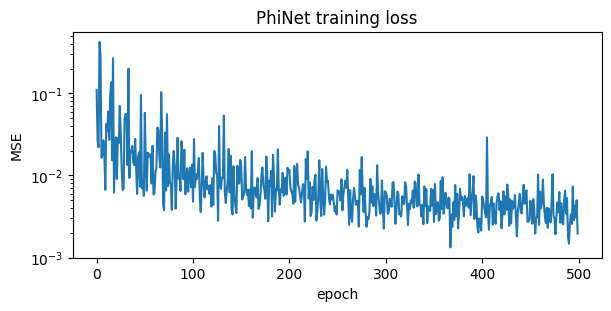

In [35]:
# ── φ network definition ──────────────────────────────────────────────────────
class PhiNet(nn.Module):
    hidden_dims: tuple = (64, 64)
    n_constraints: int = _NH_OBS

    @nn.compact
    def __call__(self, x):
        h = x
        for d in self.hidden_dims:
            h = nn.tanh(nn.Dense(d)(h))
        return nn.softplus(nn.Dense(self.n_constraints)(h))   # φ ≥ 0

phi_net    = PhiNet()
phi_params = phi_net.init(jax.random.PRNGKey(0), jnp.zeros(task_obs.nx))['params']
n_params   = sum(p.size for p in jax.tree_util.tree_leaves(phi_params))
print(f'PhiNet: {n_params} parameters')

optimizer = optax.adam(3e-3)
opt_state = optimizer.init(phi_params)

BATCH_SIZE = 256
N_EPOCHS   = 500

@jax.jit
def train_step(params, opt_state, xb, phi_b):
    def loss_fn(p):
        pred = jax.vmap(lambda x: phi_net.apply({'params': p}, x))(xb)
        return jnp.mean((pred - phi_b) ** 2)
    loss, grads = jax.value_and_grad(loss_fn)(params)
    updates, new_opt = optimizer.update(grads, opt_state, params)
    return optax.apply_updates(params, updates), new_opt, loss

rng_ep = jax.random.PRNGKey(42)
losses = []
for epoch in range(N_EPOCHS):
    rng_ep, rng_shuf = jax.random.split(rng_ep)
    perm = jax.random.permutation(rng_shuf, N_TRAIN)
    ep_loss = 0.0
    for b in range(0, N_TRAIN, BATCH_SIZE):
        idx = perm[b : b + BATCH_SIZE]
        phi_params, opt_state, ep_loss = train_step(
            phi_params, opt_state, xhat_train[idx], phi_train[idx])
    losses.append(float(ep_loss))
    if (epoch + 1) % 100 == 0:
        phi_pred_val = jax.vmap(lambda x: phi_net.apply({'params': phi_params}, x))(xhat_test)
        val_mse = float(jnp.mean((phi_pred_val - phi_test) ** 2))
        print(f'  Epoch {epoch+1:3d}  train_loss={ep_loss:.3e}  val_mse={val_mse:.3e}')

fig, ax = plt.subplots(figsize=(6, 3), layout='constrained')
ax.semilogy(losses)
ax.set(xlabel='epoch', ylabel='MSE', title='PhiNet training loss')
plt.show()

φ-CBF compiled.
  Nom+noise       safe: 0/3
  CBF+noise       safe: 2/3
  Duality CBF     safe: 3/3
  φ-CBF           safe: 3/3


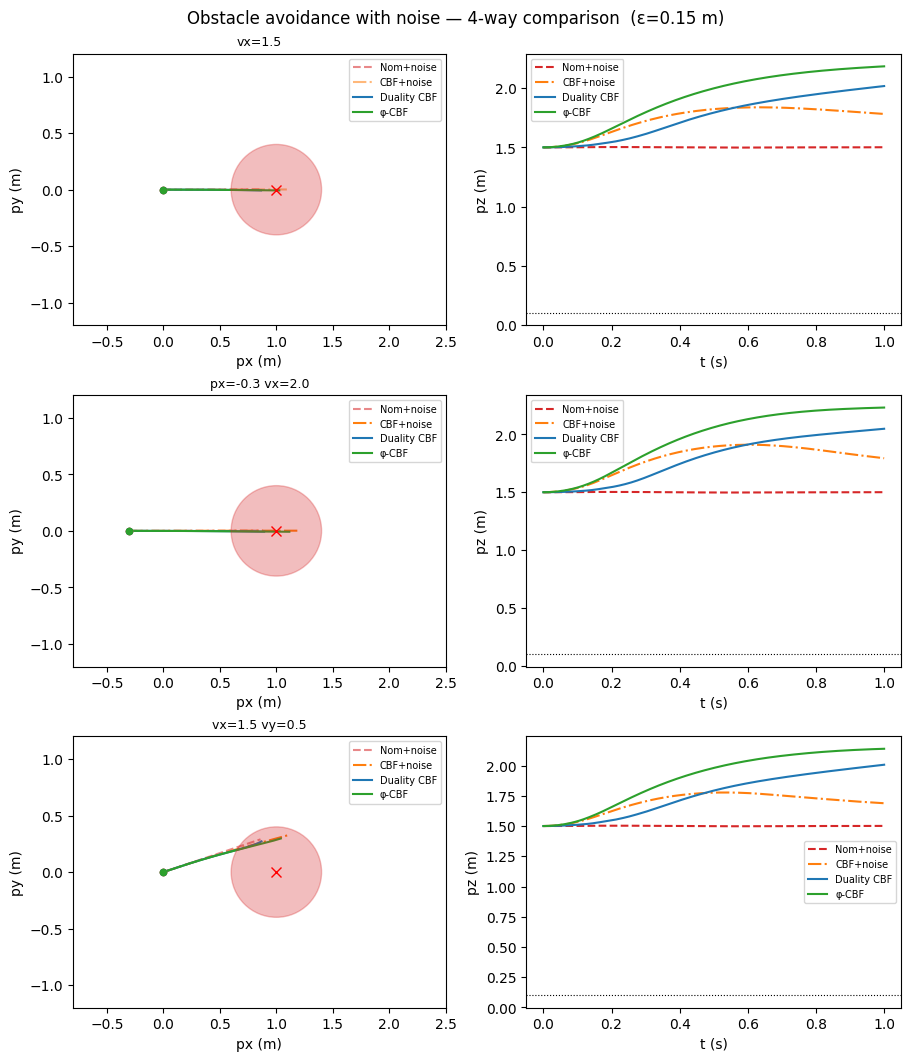

In [36]:
# ── φ-CBF step function ───────────────────────────────────────────────────────
_phi_params_frozen = phi_params   # snapshot after training

def _phi_cbf_step(x, step_idx):
    """φ-CBF: tighten barrier by learned correction, no online optimisation."""
    key   = jax.random.fold_in(BASE_KEY, step_idx)
    noise_key, _ = jax.random.split(key)
    xhat  = _perturb_dual(x, noise_key)
    phi   = phi_net.apply({'params': _phi_params_frozen}, xhat)   # (nh,)
    h_B   = task_obs.handcbf_B(xhat) + phi / ALPHA_QP             # tightened barrier
    hx_Bx = jax.jacobian(task_obs.handcbf_B)(xhat)
    u_nom = task_obs.nom_pol_hover(xhat)
    u, _, _ = min_norm_cbf(ALPHA_QP, u_lb, u_ub, h_B, hx_Bx,
                            task_obs.f(xhat), task_obs.G(xhat), u_nom, relax_eps2=0.1)
    return x + DT * task_obs.xdot(x, u), (x, xhat)

rollout_phi_cbf = _make_rollout(_phi_cbf_step)
rollout_phi_cbf(x_obs_base)   # compile
print('φ-CBF compiled.')

# ── Run all four policies ─────────────────────────────────────────────────────
pols_all = [
    ('Nom+noise',   rollout_nom_dual,  'C3', '--'),
    ('CBF+noise',   rollout_cbf_noisy, 'C1', '-.'),
    ('Duality CBF', rollout_duality,   'C0', '-' ),
    ('φ-CBF',       rollout_phi_cbf,   'C2', '-' ),
]
results_all = {}
for name, fn, col, ls in pols_all:
    trajs = []
    for x0_i in x0s_obs:
        xs, _ = jax2np(fn(x0_i))
        h_traj = jax2np(jax.vmap(task_obs.h_components)(jnp.array(xs)))
        violated = bool(np.any(h_traj.max(-1) > 0))
        trajs.append((xs, violated))
    results_all[name] = trajs
    n_safe = sum(1 for _, v in trajs if not v)
    print(f'  {name:<14}  safe: {n_safe}/{len(x0s_obs)}')

fig, axes = plt.subplots(len(x0s_obs), 2, figsize=(9, 3.5*len(x0s_obs)), layout='constrained')
for row, (x0_i, lbl) in enumerate(zip(x0s_obs, labels_obs)):
    ax_xy = axes[row, 0];  ax_pz = axes[row, 1]
    for name, fn, col, ls in pols_all:
        xs, viol = results_all[name][row]
        ax_xy.plot(xs[:, task_obs.PX], xs[:, task_obs.PY],
                   color=col, ls=ls, lw=1.5, label=name, alpha=0.55 if viol else 1.0)
        ax_xy.scatter(xs[0, task_obs.PX], xs[0, task_obs.PY], s=20, color=col, zorder=5)
        ax_pz.plot(ts, xs[:, task_obs.PZ], color=col, ls=ls, lw=1.5, label=name)
    circle = plt.Circle((cx, cy), r_obs, color='C3', alpha=0.3, zorder=3)
    ax_xy.add_patch(circle);  ax_xy.plot(cx, cy, 'rx', ms=7, zorder=4)
    ax_xy.set(xlim=(-0.8, 2.5), ylim=(-1.2, 1.2), xlabel='px (m)', ylabel='py (m)', aspect='equal')
    ax_xy.set_title(lbl, fontsize=9);  ax_xy.legend(fontsize=7)
    ax_pz.axhline(task_obs.Z_MIN, color='k', ls=':', lw=0.8)
    ax_pz.set(xlabel='t (s)', ylabel='pz (m)');  ax_pz.legend(fontsize=7)
fig.suptitle(f'Obstacle avoidance with noise — 4-way comparison  (ε={float(STATE_EPS_DUAL[0]):.2f} m)')
plt.show()

## Monte Carlo with Phi CBF

Compiling + running Monte Carlo rollouts...
  Nom+noise done.
  CBF+noise done.
  Duality CBF done.
  φ-CBF done.
Evaluating safety...
  Nom+noise       violations:  145/1000  
               rate:  14.5%  95% CI: [12.5%, 16.8%]
  CBF+noise       violations:    6/1000  
               rate:   0.6%  95% CI: [0.3%, 1.3%]
  Duality CBF     violations:    2/1000  
               rate:   0.2%  95% CI: [0.1%, 0.7%]
  φ-CBF           violations:    2/1000  
               rate:   0.2%  95% CI: [0.1%, 0.7%]


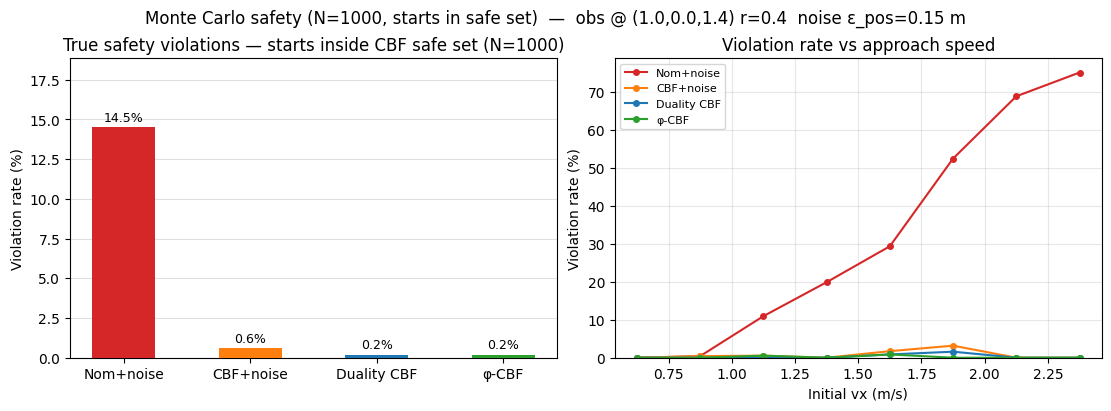

In [38]:
# # ── Sample initial conditions that lie inside the CBF safe set ────────────────
# # Only accept x0 with handcbf_B(x0).max() < 0 (inside CBF-invariant set).
# # This filters out ICs that are already unsafe or approaching too fast —
# # those are "doomed to fail" regardless of policy, so they don't test noise
# # robustness.  The true-safety check (h_components) is then meaningful.

# N_MC      = 1000
# N_CAND    = 20_000      # oversample — many candidates won't pass the filter
# # hocbf_alpha is defined in the duality cell above — change it there
# rng_mc    = np.random.default_rng(42)
# x_base    = jnp.array(task_obs.eq_state())

# # Sample candidate ICs: vary approach direction, speed, altitude, lateral vel.
# vx_cand = rng_mc.uniform(0.5,  3.0,  N_CAND)
# px_cand = rng_mc.uniform(-0.5, 0.2,  N_CAND)
# vy_cand = rng_mc.uniform(-0.8, 0.8,  N_CAND)
# pz_cand = rng_mc.uniform(1.1,  2.0,  N_CAND)
# vz_cand = rng_mc.uniform(-0.5, 0.5,  N_CAND)

# x0s_cand = jnp.array([
#     x_base.at[task_obs.VX].set(vx).at[task_obs.PX].set(px)
#            .at[task_obs.VY].set(vy).at[task_obs.PZ].set(pz)
#            .at[task_obs.VZ].set(vz)
#     for vx, px, vy, pz, vz in zip(vx_cand, px_cand, vy_cand, pz_cand, vz_cand)
# ])

# # Filter: keep only ICs inside the CBF invariant set (handcbf_B.max() < 0)
# B0 = jax2np(jax.vmap(task_obs.handcbf_B, in_axes=(0, None))(x0s_cand, hocbf_alpha))  # (N_CAND, nh)
# safe_mask = B0.max(axis=1) < 0
# n_safe = safe_mask.sum()
# print(f'Candidates: {N_CAND}  |  inside CBF safe set: {n_safe}  ({100*n_safe/N_CAND:.1f}%)')

# assert n_safe >= N_MC, (
#     f'Only {n_safe} safe ICs found — increase N_CAND or widen the sample region.')

# safe_idx  = np.where(safe_mask)[0][:N_MC]
# x0s_mc    = x0s_cand[safe_idx]
# vx_mc     = vx_cand[safe_idx]      # keep for the vx-binned plot below
# print(f'Using {N_MC} ICs, all with handcbf_B(x0).max() < 0.')

# # ── Run rollouts with vmap ─────────────────────────────────────────────────────
# mc_rollout_nom     = jax.jit(jax.vmap(rollout_nom_dual))
# mc_rollout_cbf     = jax.jit(jax.vmap(rollout_cbf_noisy))
# mc_rollout_duality = jax.jit(jax.vmap(rollout_duality))
mc_rollout_phi_cbf = jax.jit(jax.vmap(rollout_phi_cbf))

print('Compiling + running Monte Carlo rollouts...')
for name, fn in [('φ-CBF',       mc_rollout_phi_cbf)]:
    xs_all, _ = jax2np(fn(x0s_mc))   # (N_MC, T+1, nx)
    mc_trajs[name] = xs_all
    print(f'  {name} done.')

# ── Evaluate true safety: h_components > 0 at any timestep ───────────────────
print('Evaluating safety...')
h_vmap = jax.jit(jax.vmap(jax.vmap(task_obs.h_components)))  # (N, T+1, nh)

mc_results = {}
for name, xs_all in mc_trajs.items():
    h_all   = jax2np(h_vmap(jnp.array(xs_all)))     # (N_MC, T+1, nh)
    violated = h_all.max(axis=(1, 2)) > 0            # (N_MC,) bool
    mc_results[name] = violated
    n_viol = violated.sum()
    rate   = n_viol / N_MC
    z = 1.96
    lo = (rate + z**2/(2*N_MC) - z*np.sqrt(rate*(1-rate)/N_MC + z**2/(4*N_MC**2))) / (1 + z**2/N_MC)
    hi = (rate + z**2/(2*N_MC) + z*np.sqrt(rate*(1-rate)/N_MC + z**2/(4*N_MC**2))) / (1 + z**2/N_MC)
    print(f'  {name:<14}  violations: {n_viol:4}/{N_MC}  ')
    print(f'               rate: {100*rate:5.1f}%  95% CI: [{100*lo:.1f}%, {100*hi:.1f}%]')

# ── Bar chart + violation vs approach speed ───────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(11, 4), layout='constrained')
names  = list(mc_results.keys())
colors = ['C3', 'C1', 'C0', 'C2']
rates  = [mc_results[n].mean() for n in names]

axes[0].bar(names, [100*r for r in rates], color=colors, width=0.5, zorder=3)
axes[0].set(ylabel='Violation rate (%)',
            title=f'True safety violations — starts inside CBF safe set (N={N_MC})')
axes[0].set_ylim(0, max(100*max(rates)*1.3, 3))
axes[0].grid(axis='y', alpha=0.4, zorder=0)
for i, r in enumerate(rates):
    axes[0].text(i, 100*r + 0.2, f'{100*r:.1f}%', ha='center', va='bottom', fontsize=9)

bins = np.linspace(0.5, 3.0, 11)
bin_centers = 0.5*(bins[:-1] + bins[1:])
bin_idx_arr = np.digitize(vx_mc, bins) - 1
for name, color in zip(names, colors):
    viol = mc_results[name].astype(float)
    bin_rate = [viol[bin_idx_arr == b].mean() if (bin_idx_arr == b).any() else np.nan
                for b in range(len(bins)-1)]
    axes[1].plot(bin_centers, [100*r for r in bin_rate],
                 color=color, marker='o', ms=4, lw=1.5, label=name)

axes[1].set(xlabel='Initial vx (m/s)', ylabel='Violation rate (%)',
            title='Violation rate vs approach speed')
axes[1].legend(fontsize=8)
axes[1].grid(alpha=0.3)
axes[1].set_ylim(bottom=0)
fig.suptitle(
    f'Monte Carlo safety (N={N_MC}, starts in safe set)  —  ' +
    f'obs @ ({cx},{cy},{cz}) r={r_obs}  noise ε_pos={float(STATE_EPS_DUAL[0]):.2f} m')
plt.show()

## Timing

In [49]:
N_REPEATS = 5
timed_pols = [
    # ('Hand-CBF',     rollout_handcbf_obs),
    ('CBF',    rollout_cbf_noisy),
    ('Duality CBF',  rollout_duality),
    ('φ-CBF',        rollout_phi_cbf),
]
x_time = x0s_obs[0]
print(f'Timing {N_REPEATS} runs × T={T} steps per policy')
timing = {}
for name, fn in timed_pols:
    times = []
    for _ in range(N_REPEATS):
        t0 = time.perf_counter()
        jax.block_until_ready(fn(x_time))
        times.append(time.perf_counter() - t0)
    timing[name] = times
    print(f'  {name:<14}  {np.mean(times):.3f} s ± {np.std(times):.3f}')



Timing 5 runs × T=1000 steps per policy
  CBF             1.022 s ± 0.011
  Duality CBF     5.584 s ± 0.022
  φ-CBF           1.093 s ± 0.000


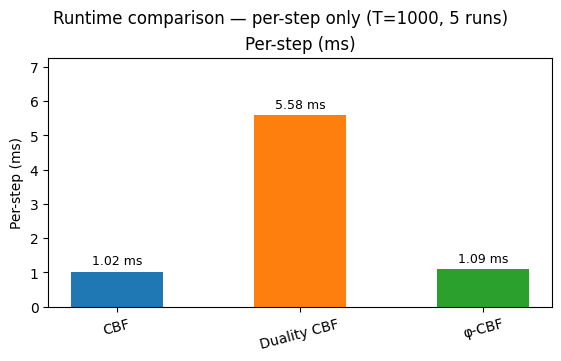

: 

In [ ]:
names    = list(timing.keys())
totals   = [np.mean(v) for v in timing.values()]
per_step = [1e3 * np.mean(v) / T for v in timing.values()]
colors   = ['C0', 'C1', 'C2', 'C4']

fig, ax = plt.subplots(1, 1, figsize=(5.5, 3.5), layout='constrained')

vals = per_step
bars = ax.bar(names, vals, color=colors[:len(names)], width=0.5)
ax.bar_label(bars, labels=[f'{v:.2f} ms' for v in vals], padding=3, fontsize=9)

ax.set_ylabel('Per-step (ms)')
ax.set_title('Per-step (ms)')
ax.tick_params(axis='x', labelrotation=15)
ax.set_ylim(0, max(vals)*1.3)
fig.suptitle(f'Runtime comparison — per-step only (T={T}, {N_REPEATS} runs)')
plt.show()